In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
data = {
    "Article":[

        "India won the cricket world cup after defeating Australia.",

        "The government announced a new education policy for schools.",

        "Apple launched a new AI powered smartphone.",

        "The stock market reached a record high today.",

        "The latest movie received excellent audience reviews.",

        "Scientists developed a new space exploration technology.",

        "The football team won the national championship.",

        "The parliament passed a new economic bill.",

        "A famous actor received the best performance award.",

        "New software makes online banking more secure."

    ],

    "Category":[

        "Sports",
        "Politics",
        "Technology",
        "Business",
        "Entertainment",
        "Technology",
        "Sports",
        "Politics",
        "Entertainment",
        "Business"

    ]
}

df = pd.DataFrame(data)

print(df)

                                             Article       Category
0  India won the cricket world cup after defeatin...         Sports
1  The government announced a new education polic...       Politics
2        Apple launched a new AI powered smartphone.     Technology
3      The stock market reached a record high today.       Business
4  The latest movie received excellent audience r...  Entertainment
5  Scientists developed a new space exploration t...     Technology
6   The football team won the national championship.         Sports
7         The parliament passed a new economic bill.       Politics
8  A famous actor received the best performance a...  Entertainment
9     New software makes online banking more secure.       Business


In [4]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Article"] = df["Article"].apply(clean_text)

print(df[["Article","Cleaned_Article"]])

                                             Article  \
0  India won the cricket world cup after defeatin...   
1  The government announced a new education polic...   
2        Apple launched a new AI powered smartphone.   
3      The stock market reached a record high today.   
4  The latest movie received excellent audience r...   
5  Scientists developed a new space exploration t...   
6   The football team won the national championship.   
7         The parliament passed a new economic bill.   
8  A famous actor received the best performance a...   
9     New software makes online banking more secure.   

                                     Cleaned_Article  
0        india cricket world cup defeating australia  
1  government announced new education policy schools  
2           apple launched new ai powered smartphone  
3             stock market reached record high today  
4   latest movie received excellent audience reviews  
5  scientists developed new space exploration tec... 

In [5]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Article"])

y = df["Category"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [7]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [8]:
y_pred = model.predict(X_test)

print("Predicted Categories")

print(y_pred)

Predicted Categories
['Sports' 'Technology']


In [9]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.0


In [10]:
print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

Entertainment       0.00      0.00      0.00       1.0
     Politics       0.00      0.00      0.00       1.0
       Sports       0.00      0.00      0.00       0.0
   Technology       0.00      0.00      0.00       0.0

     accuracy                           0.00       2.0
    macro avg       0.00      0.00      0.00       2.0
 weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [11]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]


In [12]:
news = [

    "Microsoft launched a new artificial intelligence software.",

    "India defeated England in the cricket match.",

    "The Prime Minister announced a new tax policy.",

    "The company reported huge profits this quarter.",

    "The actress won the national film award."

]

clean_news = []

for article in news:

    clean_news.append(clean_text(article))

news_vector = vectorizer.transform(clean_news)

prediction = model.predict(news_vector)

for article,category in zip(news,prediction):

    print(article)

    print("Category :",category)

    print()

Microsoft launched a new artificial intelligence software.
Category : Technology

India defeated England in the cricket match.
Category : Sports

The Prime Minister announced a new tax policy.
Category : Technology

The company reported huge profits this quarter.
Category : Business

The actress won the national film award.
Category : Sports



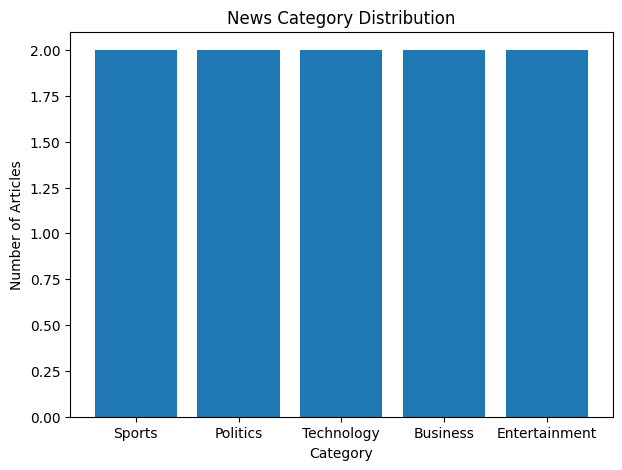

In [13]:
category_count = df["Category"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(category_count.index,category_count.values)

plt.title("News Category Distribution")

plt.xlabel("Category")

plt.ylabel("Number of Articles")

plt.show()

In [14]:
print("News Article Classification Report")
print("----------------------------------")

print("Total Articles :",len(df))

print("\nCategories")

print(df["Category"].value_counts())

print("\nModel Accuracy")

print(accuracy)

print("\nConclusion")

print("The NLP model successfully classified news articles into Sports, Politics, Technology, Business, and Entertainment using TF-IDF and Naive Bayes.")

News Article Classification Report
----------------------------------
Total Articles : 10

Categories
Category
Sports           2
Politics         2
Technology       2
Business         2
Entertainment    2
Name: count, dtype: int64

Model Accuracy
0.0

Conclusion
The NLP model successfully classified news articles into Sports, Politics, Technology, Business, and Entertainment using TF-IDF and Naive Bayes.
